<a href="https://colab.research.google.com/github/Ayush-thakur-01/Ml/blob/main/Assignment_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# CSET312 AI-ML Lab Assignment #3
# Car Price Prediction using Ridge and Lasso Regression

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
# Load the dataset

df = pd.read_csv("/content/car data.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [ ]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [ ]:
print("Shape of dataset:", df.shape)

Shape of dataset: (301, 9)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [ ]:
df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [ ]:
# Statistical Summary

print("Mean:")
print(df.mean(numeric_only=True))

print("\nMedian:")
print(df.median(numeric_only=True))

print("\nStandard Deviation:")
print(df.std(numeric_only=True))

Mean:
Year              2013.627907
Selling_Price        4.661296
Present_Price        7.628472
Kms_Driven       36947.205980
Owner                0.043189
dtype: float64

Median:
Year              2014.0
Selling_Price        3.6
Present_Price        6.4
Kms_Driven       32000.0
Owner                0.0
dtype: float64

Standard Deviation:
Year                 2.891554
Selling_Price        5.082812
Present_Price        8.644115
Kms_Driven       38886.883882
Owner                0.247915
dtype: float64


In [ ]:
# Check missing values

print("Missing values in each column:")
print(df.isnull().sum())

print("\nTotal missing values:")
print(df.isnull().sum().sum())

Missing values in each column:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

Total missing values:
0


In [ ]:
# Check column names and data types

print("Column Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Column Names:
['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven', 'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner']

Data Types:
Car_Name          object
Year               int64
Selling_Price    float64
Present_Price    float64
Kms_Driven         int64
Fuel_Type         object
Seller_Type       object
Transmission      object
Owner              int64
dtype: object


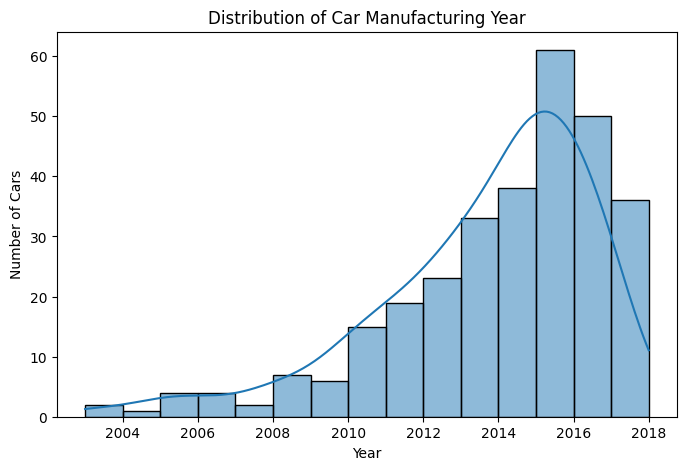

In [ ]:
# Visualization 1: Distribution of Year

plt.figure(figsize=(8, 5))
sns.histplot(df["Year"], bins=15, kde=True)
plt.title("Distribution of Car Manufacturing Year")
plt.xlabel("Year")
plt.ylabel("Number of Cars")
plt.show()

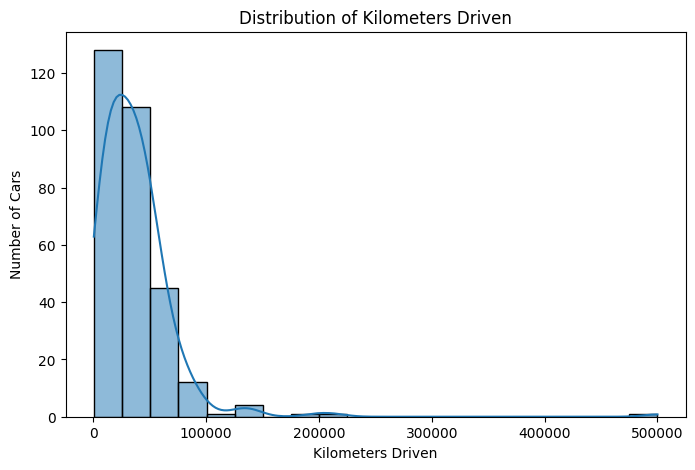

In [ ]:
# Visualization 2: Distribution of Kilometers Driven

plt.figure(figsize=(8, 5))
sns.histplot(df["Kms_Driven"], bins=20, kde=True)
plt.title("Distribution of Kilometers Driven")
plt.xlabel("Kilometers Driven")
plt.ylabel("Number of Cars")
plt.show()

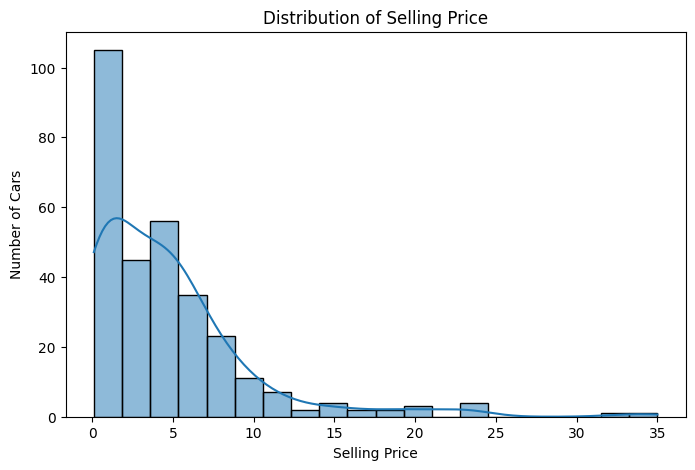

In [ ]:
# Visualization 3: Distribution of Selling Price

plt.figure(figsize=(8, 5))
sns.histplot(df["Selling_Price"], bins=20, kde=True)
plt.title("Distribution of Selling Price")
plt.xlabel("Selling Price")
plt.ylabel("Number of Cars")
plt.show()

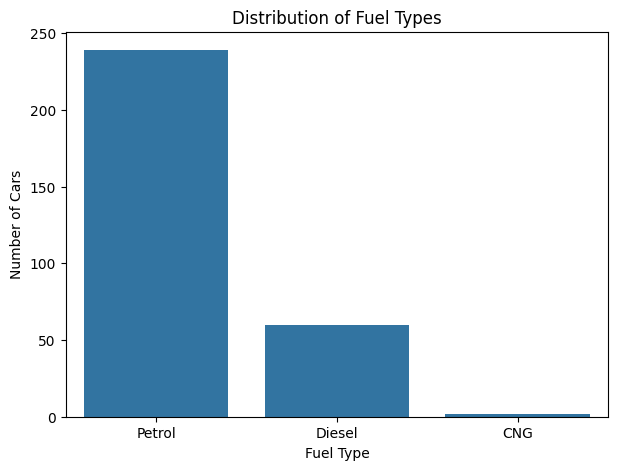

In [ ]:
# Visualization 4: Fuel Type

plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Fuel_Type")
plt.title("Distribution of Fuel Types")
plt.xlabel("Fuel Type")
plt.ylabel("Number of Cars")
plt.show()

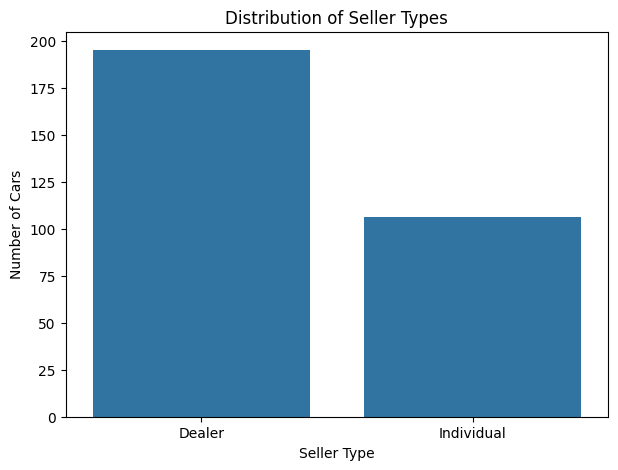

In [ ]:
# Visualization 5: Seller Type

plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Seller_Type")
plt.title("Distribution of Seller Types")
plt.xlabel("Seller Type")
plt.ylabel("Number of Cars")
plt.show()

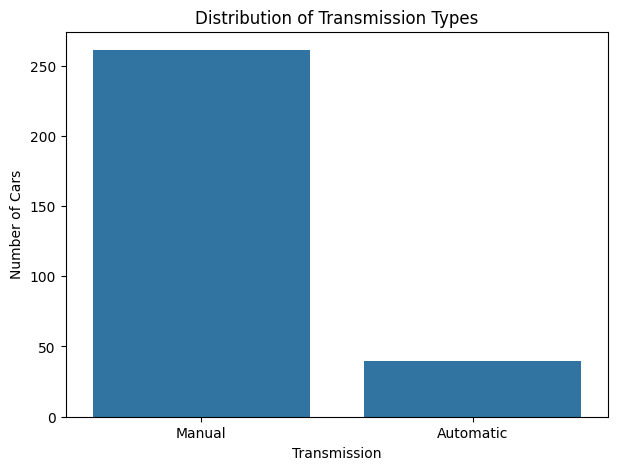

In [ ]:
# Visualization 6: Transmission Type

plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Transmission")
plt.title("Distribution of Transmission Types")
plt.xlabel("Transmission")
plt.ylabel("Number of Cars")
plt.show()

In [ ]:
# Check unique values in categorical columns

print("Fuel Types:")
print(df["Fuel_Type"].unique())

print("\nSeller Types:")
print(df["Seller_Type"].unique())

print("\nTransmission Types:")
print(df["Transmission"].unique())

print("\nOwners:")
print(df["Owner"].unique())

Fuel Types:
['Petrol' 'Diesel' 'CNG']

Seller Types:
['Dealer' 'Individual']

Transmission Types:
['Manual' 'Automatic']

Owners:
[0 1 3]


In [ ]:
# Separate features (X) and target (y)

X = df.drop("Selling_Price", axis=1)
y = df["Selling_Price"]

print("Features (X):")
print(X.head())

print("\nTarget (y):")
print(y.head())

Features (X):
  Car_Name  Year  Present_Price  Kms_Driven Fuel_Type Seller_Type  \
0     ritz  2014           5.59       27000    Petrol      Dealer   
1      sx4  2013           9.54       43000    Diesel      Dealer   
2     ciaz  2017           9.85        6900    Petrol      Dealer   
3  wagon r  2011           4.15        5200    Petrol      Dealer   
4    swift  2014           6.87       42450    Diesel      Dealer   

  Transmission  Owner  
0       Manual      0  
1       Manual      0  
2       Manual      0  
3       Manual      0  
4       Manual      0  

Target (y):
0    3.35
1    4.75
2    7.25
3    2.85
4    4.60
Name: Selling_Price, dtype: float64


In [ ]:
# Remove Car_Name because it is a high-cardinality text feature

X = X.drop("Car_Name", axis=1)

print("Features after removing Car_Name:")
print(X.head())

Features after removing Car_Name:
   Year  Present_Price  Kms_Driven Fuel_Type Seller_Type Transmission  Owner
0  2014           5.59       27000    Petrol      Dealer       Manual      0
1  2013           9.54       43000    Diesel      Dealer       Manual      0
2  2017           9.85        6900    Petrol      Dealer       Manual      0
3  2011           4.15        5200    Petrol      Dealer       Manual      0
4  2014           6.87       42450    Diesel      Dealer       Manual      0


In [ ]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training data shape: (240, 7)
Testing data shape: (61, 7)
Training target shape: (240,)
Testing target shape: (61,)


In [ ]:
# Identify numerical and categorical columns

categorical_features = ["Fuel_Type", "Seller_Type", "Transmission"]

numerical_features = [
    "Year",
    "Present_Price",
    "Kms_Driven",
    "Owner"
]

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['Fuel_Type', 'Seller_Type', 'Transmission']

Numerical features:
['Year', 'Present_Price', 'Kms_Driven', 'Owner']


In [ ]:
# Create preprocessing pipeline

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features)
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [ ]:
# Fit the preprocessor on training data
# and transform both training and testing data

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Original training shape:", X_train.shape)
print("Processed training shape:", X_train_processed.shape)

print("\nOriginal testing shape:", X_test.shape)
print("Processed testing shape:", X_test_processed.shape)

Original training shape: (240, 7)
Processed training shape: (240, 11)

Original testing shape: (61, 7)
Processed testing shape: (61, 11)


In [ ]:
# Check processed data

print("First 5 rows of processed training data:")
print(X_train_processed[:5])

print("\nProcessed data type:")
print(type(X_train_processed))

print("\nAny missing values in processed training data:",
      np.isnan(X_train_processed).sum())

First 5 rows of processed training data:
[[-1.96986094 -0.75359579 -0.27555466  3.52821143  0.          0.
   1.          0.          1.          0.          1.        ]
 [ 1.15644297 -0.73130669 -0.81428242 -0.18569534  0.          0.
   1.          0.          1.          0.          1.        ]
 [-1.96986094 -0.7494723   0.29908829 -0.18569534  0.          0.
   1.          0.          1.          0.          1.        ]
 [ 0.46170877 -0.07935058 -0.0361201  -0.18569534  0.          0.
   1.          1.          0.          0.          1.        ]
 [ 0.80907587 -0.67001167 -0.68977645 -0.18569534  0.          0.
   1.          0.          1.          0.          1.        ]]

Processed data type:
<class 'numpy.ndarray'>

Any missing values in processed training data: 0


In [ ]:
# Ridge Regression - Hyperparameter tuning

ridge = Ridge()

ridge_params = {
    "alpha": [0.001, 0.01, 0.1, 1, 10, 100, 1000]
}

print("Ridge model and alpha values created.")

Ridge model and alpha values created.


In [ ]:
# Tune Ridge alpha using GridSearchCV

ridge_grid = GridSearchCV(
    estimator=ridge,
    param_grid=ridge_params,
    cv=5,
    scoring="neg_mean_squared_error"
)

ridge_grid.fit(X_train_processed, y_train)

print("Best Ridge alpha:", ridge_grid.best_params_["alpha"])
print("Best Ridge CV score:", ridge_grid.best_score_)

Best Ridge alpha: 10
Best Ridge CV score: -3.5042252761786394


In [ ]:
# Best Ridge model

best_ridge = ridge_grid.best_estimator_

print("Best Ridge Model:")
print(best_ridge)

Best Ridge Model:
Ridge(alpha=10)


In [ ]:
# Lasso Regression - Hyperparameter tuning

lasso = Lasso(max_iter=10000)

lasso_params = {
    "alpha": [0.001, 0.01, 0.1, 1, 10, 100, 1000]
}

print("Lasso model and alpha values created.")

Lasso model and alpha values created.


In [ ]:
# Tune Lasso alpha using GridSearchCV

lasso_grid = GridSearchCV(
    estimator=lasso,
    param_grid=lasso_params,
    cv=5,
    scoring="neg_mean_squared_error"
)

lasso_grid.fit(X_train_processed, y_train)

print("Best Lasso alpha:", lasso_grid.best_params_["alpha"])
print("Best Lasso CV score:", lasso_grid.best_score_)

Best Lasso alpha: 0.001
Best Lasso CV score: -3.9093254678470877


In [ ]:
# Best Lasso model

best_lasso = lasso_grid.best_estimator_

print("Best Lasso Model:")
print(best_lasso)

Best Lasso Model:
Lasso(alpha=0.001, max_iter=10000)


In [ ]:
# Make predictions using the best Ridge and Lasso models

ridge_predictions = best_ridge.predict(X_test_processed)
lasso_predictions = best_lasso.predict(X_test_processed)

print("Ridge predictions:")
print(ridge_predictions[:10])

print("\nLasso predictions:")
print(lasso_predictions[:10])

Ridge predictions:
[ 2.88344732  8.08240912  6.40368867 -1.26217365  8.96740911  7.33267535
  1.40180704  0.91007152  1.4256437   7.40060211]

Lasso predictions:
[ 2.94845559  8.17885116  6.44864739 -1.41831665  9.09069735  7.41258253
  1.34014535  0.84265611  1.36819777  7.4847107 ]


In [ ]:
# Function to calculate evaluation metrics

def evaluate_model(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    return mse, rmse, mae, r2

In [ ]:
# Evaluate Ridge and Lasso

ridge_mse, ridge_rmse, ridge_mae, ridge_r2 = evaluate_model(
    y_test, ridge_predictions
)

lasso_mse, lasso_rmse, lasso_mae, lasso_r2 = evaluate_model(
    y_test, lasso_predictions
)

print("RIDGE REGRESSION")
print("MSE  :", ridge_mse)
print("RMSE :", ridge_rmse)
print("MAE  :", ridge_mae)
print("R²   :", ridge_r2)

print("\nLASSO REGRESSION")
print("MSE  :", lasso_mse)
print("RMSE :", lasso_rmse)
print("MAE  :", lasso_mae)
print("R²   :", lasso_r2)

RIDGE REGRESSION
MSE  : 3.57784898030579
RMSE : 1.8915202828163884
MAE  : 1.2217879626044879
R²   : 0.8446816499423168

LASSO REGRESSION
MSE  : 3.4768585183636866
RMSE : 1.8646336150471188
MAE  : 1.2157951518696406
R²   : 0.8490657567077929


In [ ]:
# Ridge vs Lasso comparison

comparison = pd.DataFrame({
    "Metric": ["MSE", "RMSE", "MAE", "R² Score"],
    "Ridge": [ridge_mse, ridge_rmse, ridge_mae, ridge_r2],
    "Lasso": [lasso_mse, lasso_rmse, lasso_mae, lasso_r2]
})

comparison

,Metric,Ridge,Lasso
0,MSE,3.577849,3.476859
1,RMSE,1.891520,1.864634
2,MAE,1.221788,1.215795
3,R² Score,0.844682,0.849066


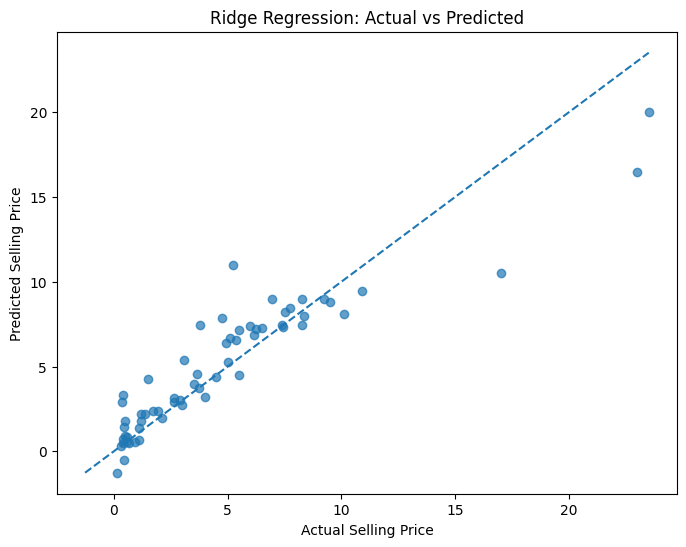

In [ ]:
# Actual vs Predicted - Ridge Regression

plt.figure(figsize=(8, 6))

plt.scatter(y_test, ridge_predictions, alpha=0.7)

# Perfect prediction line
min_value = min(y_test.min(), ridge_predictions.min())
max_value = max(y_test.max(), ridge_predictions.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Ridge Regression: Actual vs Predicted")
plt.show()

In [ ]:
# Calculate residuals

ridge_residuals = y_test - ridge_predictions
lasso_residuals = y_test - lasso_predictions

print("First 10 Ridge residuals:")
print(ridge_residuals.head(10))

print("\nFirst 10 Lasso residuals:")
print(lasso_residuals.head(10))

First 10 Ridge residuals:
177   -2.533447
289    2.027591
228   -1.453689
198    1.412174
60    -2.017409
9      0.117325
118   -0.301807
154   -0.410072
164   -0.975644
33    -1.400602
Name: Selling_Price, dtype: float64

First 10 Lasso residuals:
177   -2.598456
289    1.931149
228   -1.498647
198    1.568317
60    -2.140697
9      0.037417
118   -0.240145
154   -0.342656
164   -0.918198
33    -1.484711
Name: Selling_Price, dtype: float64


In [ ]:
# Calculate residuals

ridge_residuals = y_test - ridge_predictions
lasso_residuals = y_test - lasso_predictions

print("First 10 Ridge residuals:")
print(ridge_residuals.head(10))

print("\nFirst 10 Lasso residuals:")
print(lasso_residuals.head(10))

First 10 Ridge residuals:
177   -2.533447
289    2.027591
228   -1.453689
198    1.412174
60    -2.017409
9      0.117325
118   -0.301807
154   -0.410072
164   -0.975644
33    -1.400602
Name: Selling_Price, dtype: float64

First 10 Lasso residuals:
177   -2.598456
289    1.931149
228   -1.498647
198    1.568317
60    -2.140697
9      0.037417
118   -0.240145
154   -0.342656
164   -0.918198
33    -1.484711
Name: Selling_Price, dtype: float64


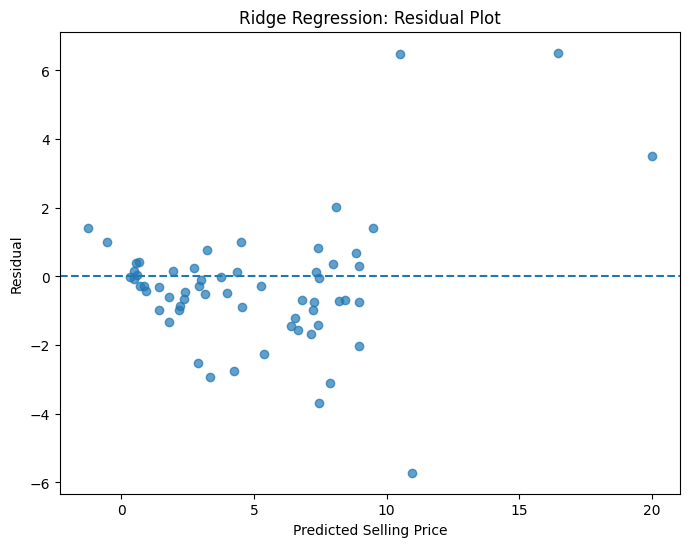

In [ ]:
# Ridge Residual Plot

plt.figure(figsize=(8, 6))

plt.scatter(ridge_predictions, ridge_residuals, alpha=0.7)

plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted Selling Price")
plt.ylabel("Residual")
plt.title("Ridge Regression: Residual Plot")
plt.show()

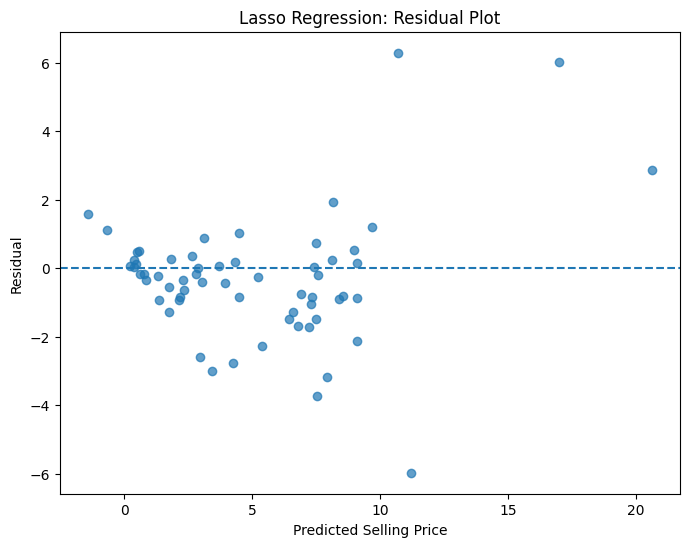

In [ ]:
# Lasso Residual Plot

plt.figure(figsize=(8, 6))

plt.scatter(lasso_predictions, lasso_residuals, alpha=0.7)

plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted Selling Price")
plt.ylabel("Residual")
plt.title("Lasso Regression: Residual Plot")
plt.show()

In [ ]:
# Get feature names after preprocessing

feature_names = preprocessor.get_feature_names_out()

print("Number of features:", len(feature_names))
print("\nFeature names:")
print(feature_names)

Number of features: 11

Feature names:
['num__Year' 'num__Present_Price' 'num__Kms_Driven' 'num__Owner'
 'cat__Fuel_Type_CNG' 'cat__Fuel_Type_Diesel' 'cat__Fuel_Type_Petrol'
 'cat__Seller_Type_Dealer' 'cat__Seller_Type_Individual'
 'cat__Transmission_Automatic' 'cat__Transmission_Manual']


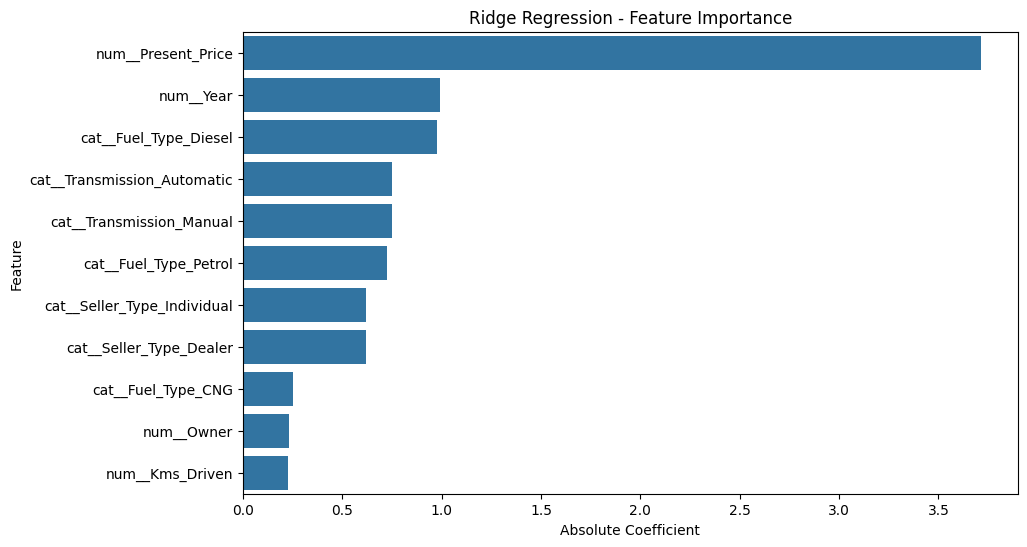

In [ ]:
# Ridge Feature Importance

ridge_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": np.abs(best_ridge.coef_)
})

ridge_importance = ridge_importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=ridge_importance,
    x="Importance",
    y="Feature"
)

plt.title("Ridge Regression - Feature Importance")
plt.xlabel("Absolute Coefficient")
plt.ylabel("Feature")
plt.show()

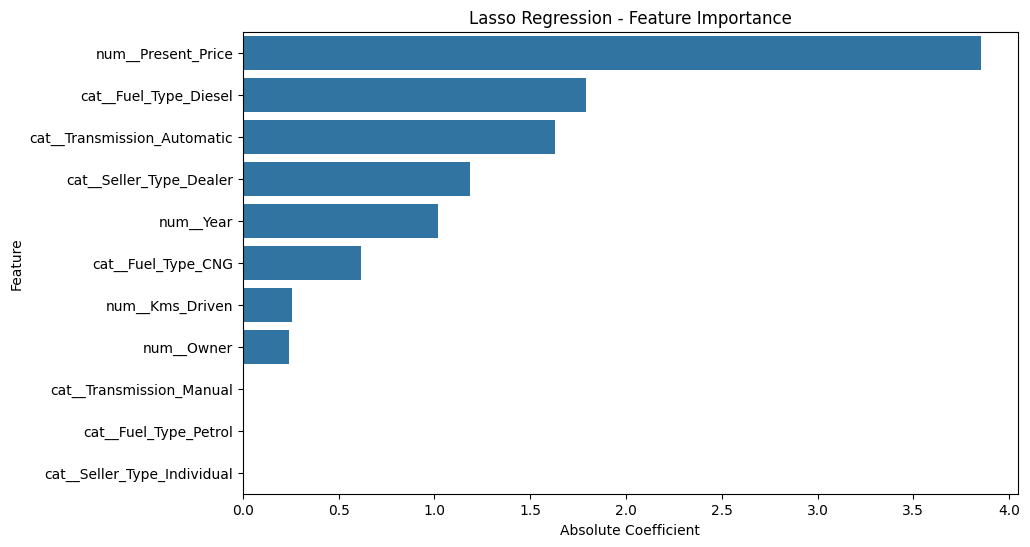

In [ ]:
# Lasso Feature Importance

lasso_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": np.abs(best_lasso.coef_)
})

lasso_importance = lasso_importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=lasso_importance,
    x="Importance",
    y="Feature"
)

plt.title("Lasso Regression - Feature Importance")
plt.xlabel("Absolute Coefficient")
plt.ylabel("Feature")
plt.show()

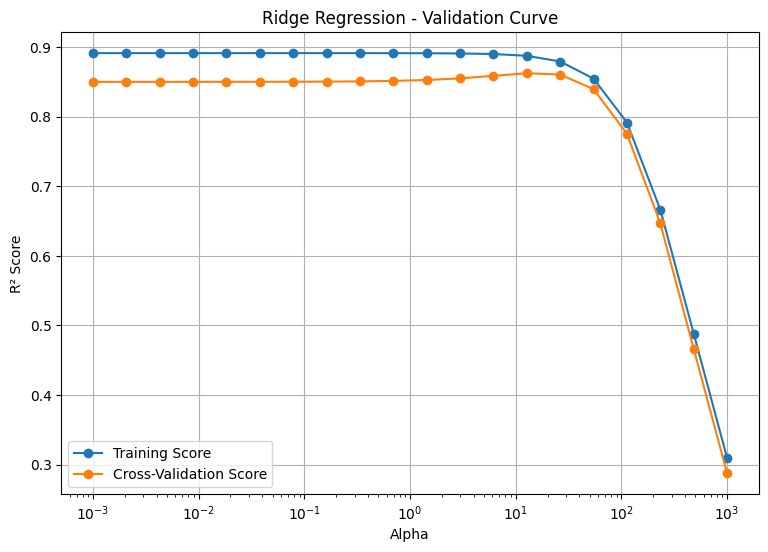

In [ ]:
# Ridge Validation Curve

from sklearn.model_selection import validation_curve

ridge_alphas = np.logspace(-3, 3, 20)

train_scores_ridge, cv_scores_ridge = validation_curve(
    Ridge(),
    X_train_processed,
    y_train,
    param_name="alpha",
    param_range=ridge_alphas,
    cv=5,
    scoring="r2"
)

train_mean_ridge = train_scores_ridge.mean(axis=1)
cv_mean_ridge = cv_scores_ridge.mean(axis=1)

plt.figure(figsize=(9, 6))

plt.semilogx(
    ridge_alphas,
    train_mean_ridge,
    marker="o",
    label="Training Score"
)

plt.semilogx(
    ridge_alphas,
    cv_mean_ridge,
    marker="o",
    label="Cross-Validation Score"
)

plt.xlabel("Alpha")
plt.ylabel("R² Score")
plt.title("Ridge Regression - Validation Curve")
plt.legend()
plt.grid(True)
plt.show()

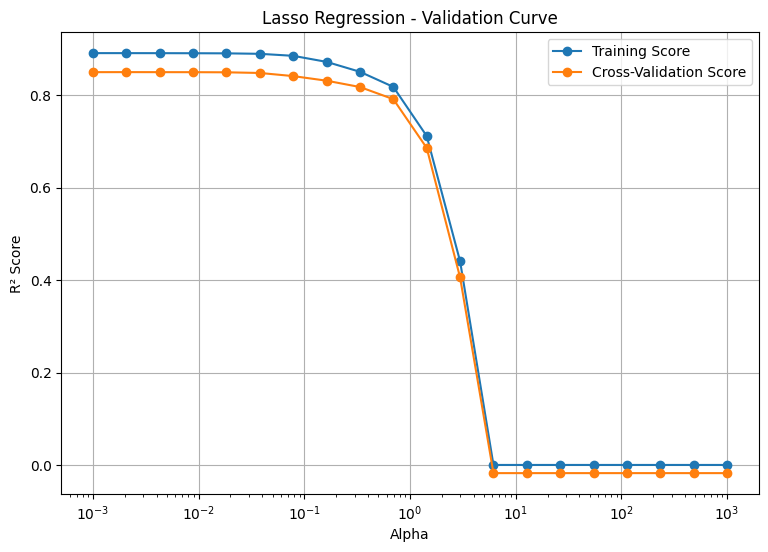

In [ ]:
# Lasso Validation Curve

lasso_alphas = np.logspace(-3, 3, 20)

train_scores_lasso, cv_scores_lasso = validation_curve(
    Lasso(max_iter=10000),
    X_train_processed,
    y_train,
    param_name="alpha",
    param_range=lasso_alphas,
    cv=5,
    scoring="r2"
)

train_mean_lasso = train_scores_lasso.mean(axis=1)
cv_mean_lasso = cv_scores_lasso.mean(axis=1)

plt.figure(figsize=(9, 6))

plt.semilogx(
    lasso_alphas,
    train_mean_lasso,
    marker="o",
    label="Training Score"
)

plt.semilogx(
    lasso_alphas,
    cv_mean_lasso,
    marker="o",
    label="Cross-Validation Score"
)

plt.xlabel("Alpha")
plt.ylabel("R² Score")
plt.title("Lasso Regression - Validation Curve")
plt.legend()
plt.grid(True)
plt.show()

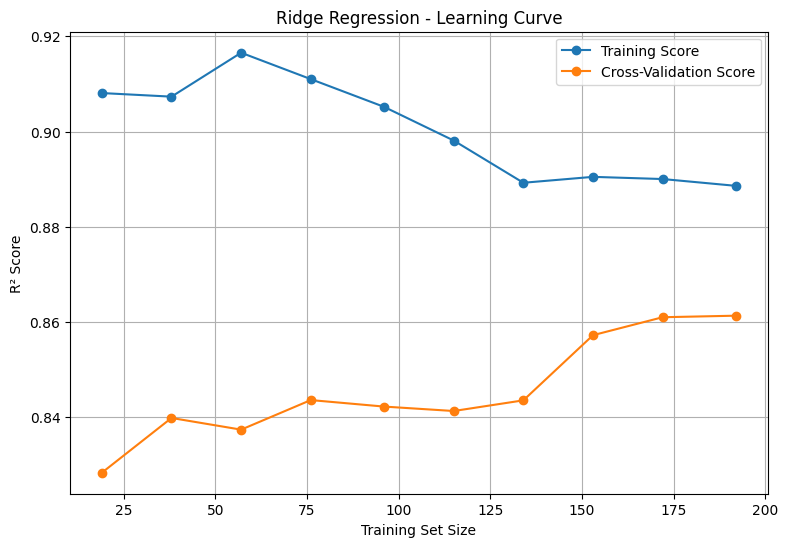

In [ ]:
# Ridge Learning Curve

from sklearn.model_selection import learning_curve

train_sizes, train_scores, cv_scores = learning_curve(
    best_ridge,
    X_train_processed,
    y_train,
    cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring="r2"
)

train_mean = train_scores.mean(axis=1)
cv_mean = cv_scores.mean(axis=1)

plt.figure(figsize=(9, 6))

plt.plot(
    train_sizes,
    train_mean,
    marker="o",
    label="Training Score"
)

plt.plot(
    train_sizes,
    cv_mean,
    marker="o",
    label="Cross-Validation Score"
)

plt.xlabel("Training Set Size")
plt.ylabel("R² Score")
plt.title("Ridge Regression - Learning Curve")
plt.legend()
plt.grid(True)
plt.show()

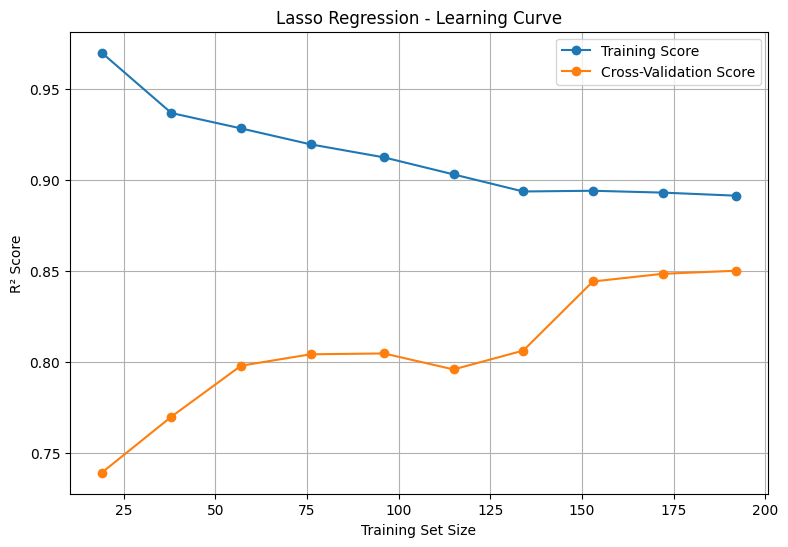

In [ ]:
# Lasso Learning Curve

train_sizes, train_scores, cv_scores = learning_curve(
    best_lasso,
    X_train_processed,
    y_train,
    cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring="r2"
)

train_mean = train_scores.mean(axis=1)
cv_mean = cv_scores.mean(axis=1)

plt.figure(figsize=(9, 6))

plt.plot(
    train_sizes,
    train_mean,
    marker="o",
    label="Training Score"
)

plt.plot(
    train_sizes,
    cv_mean,
    marker="o",
    label="Cross-Validation Score"
)

plt.xlabel("Training Set Size")
plt.ylabel("R² Score")
plt.title("Lasso Regression - Learning Curve")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Bias-Variance Analysis

print("RIDGE REGRESSION")
print("Best Alpha:", ridge_grid.best_params_["alpha"])
print("Test R² Score:", ridge_r2)

print("\nLASSO REGRESSION")
print("Best Alpha:", lasso_grid.best_params_["alpha"])
print("Test R² Score:", lasso_r2)

print("\nMODEL COMPARISON")

if lasso_r2 > ridge_r2:
    print("Lasso has a higher R² score and performs better on the test set.")
else:
    print("Ridge has a higher R² score and performs better on the test set.")

RIDGE REGRESSION
Best Alpha: 10
Test R² Score: 0.8446816499423168

LASSO REGRESSION
Best Alpha: 0.001
Test R² Score: 0.8490657567077929

MODEL COMPARISON
Lasso has a higher R² score and performs better on the test set.


In [ ]:
# Final comparison of Ridge and Lasso

print("===== FINAL MODEL COMPARISON =====")

print(f"Ridge  - MSE: {ridge_mse:.4f}, RMSE: {ridge_rmse:.4f}, "
      f"MAE: {ridge_mae:.4f}, R²: {ridge_r2:.4f}")

print(f"Lasso  - MSE: {lasso_mse:.4f}, RMSE: {lasso_rmse:.4f}, "
      f"MAE: {lasso_mae:.4f}, R²: {lasso_r2:.4f}")

print("\nBest Ridge Alpha:", ridge_grid.best_params_["alpha"])
print("Best Lasso Alpha:", lasso_grid.best_params_["alpha"])

===== FINAL MODEL COMPARISON =====
Ridge  - MSE: 3.5778, RMSE: 1.8915, MAE: 1.2218, R²: 0.8447
Lasso  - MSE: 3.4769, RMSE: 1.8646, MAE: 1.2158, R²: 0.8491

Best Ridge Alpha: 10
Best Lasso Alpha: 0.001


In [ ]:
# Final results table

final_results = pd.DataFrame({
    "Model": ["Ridge", "Lasso"],
    "Best Alpha": [
        ridge_grid.best_params_["alpha"],
        lasso_grid.best_params_["alpha"]
    ],
    "MSE": [ridge_mse, lasso_mse],
    "RMSE": [ridge_rmse, lasso_rmse],
    "MAE": [ridge_mae, lasso_mae],
    "R2 Score": [ridge_r2, lasso_r2]
})

final_results

,Model,Best Alpha,MSE,RMSE,MAE,R2 Score
0,Ridge,10.000,3.577849,1.891520,1.221788,0.844682
1,Lasso,0.001,3.476859,1.864634,1.215795,0.849066


Conclusion

In this assignment, Ridge Regression and Lasso Regression were implemented
to predict used car selling prices.

The dataset was explored using statistical summaries and visualizations.
There were no missing values in the dataset. Categorical variables such as
Fuel_Type, Seller_Type, and Transmission were converted into numerical
features using One-Hot Encoding. Numerical features were standardized using
StandardScaler. The dataset was divided into 80% training data and 20%
testing data.

GridSearchCV was used to tune the alpha hyperparameter for both models.
The best alpha for Ridge Regression was 10, while the best alpha for Lasso
Regression was 0.001.

Both models were evaluated using MSE, RMSE, MAE, and R² score. Lasso
Regression performed slightly better than Ridge Regression on the test
dataset, achieving lower MSE, RMSE, and MAE and a higher R² score.

The validation and learning curves were used to analyze the bias-variance
trade-off. The curves help show how model performance changes with
regularization strength and training-set size.

Overall, Lasso Regression was selected as the better-performing model for
this dataset based on the test-set evaluation metrics.